In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
# Load the processed master dataset
df = pd.read_csv(
    "../data/processed/master_sales_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date"
    ]
)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (113425, 43)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_day,purchase_weekday,delivery_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,payment_count,review_score,review_count,review_comment_title,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2,Monday,8.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP,38.71,1.0,"credit_card, voucher",3.0,4.0,1.0,NaN,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,24,Tuesday,13.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP,141.46,1.0,boleto,1.0,4.0,1.0,Muito boa a loja,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,8,Wednesday,9.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840.0,guariba,SP,179.12,3.0,credit_card,1.0,5.0,1.0,NaN,NaN
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,18,Saturday,13.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,31842.0,belo horizonte,MG,72.20,1.0,credit_card,1.0,5.0,1.0,NaN,O produto foi exatamente o que eu esperava e e...
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,13,Tuesday,2.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,8752.0,mogi das cruzes,SP,28.62,1.0,credit_card,1.0,5.0,1.0,NaN,NaN


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  object        
 5   order_delivered_carrier_date   111457 non-null  object        
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113425 non-null  object        
 8   purchase_year                  113425 non-null  int64         
 9   purchase_month                 113425 non-null  int64         
 10  purchase_day                   113425 non-null  int64         
 11  

In [50]:
customer_features = (
    df.groupby("customer_unique_id")
      .agg(
          total_orders=("order_id", "nunique"),
          total_spent=("payment_value", "sum"),
          avg_order_value=("payment_value", "mean"),
          avg_review_score=("review_score", "mean"),
          avg_delivery_days=("delivery_days", "mean"),
          first_purchase=("order_purchase_timestamp", "min"),
          last_purchase=("order_purchase_timestamp", "max")
      )
      .reset_index()
)

In [51]:
customer_features["customer_tenure_days"] = (
    customer_features["last_purchase"] -
    customer_features["first_purchase"]
).dt.days

In [52]:
customer_features["avg_review_score"] = (
    customer_features["avg_review_score"]
    .fillna(customer_features["avg_review_score"].median())
)

customer_features["avg_delivery_days"] = (
    customer_features["avg_delivery_days"]
    .fillna(customer_features["avg_delivery_days"].median())
)

In [53]:
print(customer_features.shape)

customer_features.head()

(96096, 9)


,customer_unique_id,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,first_purchase,last_purchase,customer_tenure_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.0,6.0,2018-05-10 10:56:27,2018-05-10 10:56:27,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0,3.0,2018-05-07 11:11:27,2018-05-07 11:11:27,0
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0,25.0,2017-03-10 21:05:03,2017-03-10 21:05:03,0
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,20.0,2017-10-12 20:29:41,2017-10-12 20:29:41,0
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0,13.0,2017-11-14 19:45:42,2017-11-14 19:45:42,0


In [54]:
customer_features.describe().T

,count,mean,min,25%,50%,75%,max,std
total_orders,96096.0,1.034809,1.0,1.0,1.0,1.0,17.0,0.214384
total_spent,96096.0,213.023712,0.0,63.99,113.15,202.7325,109312.64,640.917083
avg_order_value,96095.0,161.539532,0.0,62.48,105.86,177.36,13664.08,222.463145
avg_review_score,96096.0,4.091491,1.0,4.0,5.0,5.0,5.0,1.339395
avg_delivery_days,96096.0,12.041984,0.0,6.0,10.0,15.0,209.0,9.421751
first_purchase,96096,2017-12-30 19:19:10.429206016,2016-09-04 21:15:19,2017-09-11 19:52:06,2018-01-18 13:33:08,2018-05-04 10:38:45,2018-10-17 17:30:18,NaN
last_purchase,96096,2018-01-02 12:40:19.655864832,2016-09-04 21:15:19,2017-09-15 09:04:17.249999872,2018-01-21 19:39:16,2018-05-06 20:14:49.750000128,2018-10-17 17:30:18,NaN
customer_tenure_days,96096.0,2.711507,0.0,0.0,0.0,0.0,633.0,25.393343


In [55]:
customer_features.isnull().sum()

customer_unique_id      0
total_orders            0
total_spent             0
avg_order_value         1
avg_review_score        0
avg_delivery_days       0
first_purchase          0
last_purchase           0
customer_tenure_days    0
dtype: int64

In [56]:
customer_features[customer_features["avg_order_value"].isna()]

,customer_unique_id,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,first_purchase,last_purchase,customer_tenure_days
49312,830d5b7aaa3b6f1e9ad63703bec97d23,1,0.0,NaN,1.0,54.0,2016-09-15 12:16:38,2016-09-15 12:16:38,0


In [57]:
customer_features["avg_order_value"] = (
    customer_features["avg_order_value"]
    .fillna(customer_features["avg_order_value"].median())
)

In [58]:
customer_features.isnull().sum()

customer_unique_id      0
total_orders            0
total_spent             0
avg_order_value         0
avg_review_score        0
avg_delivery_days       0
first_purchase          0
last_purchase           0
customer_tenure_days    0
dtype: int64

In [59]:
# Save customer features
customer_features.to_csv(
    "../data/processed/customer_features.csv",
    index=False
)

print("Customer features saved successfully!")

Customer features saved successfully!


In [60]:
customer_features = pd.read_csv(
    "../data/processed/customer_features.csv",
    parse_dates=["first_purchase", "last_purchase"]
)

In [61]:
features = [
    "total_orders",
    "total_spent",
    "avg_order_value",
    "avg_review_score",
    "avg_delivery_days",
    "customer_tenure_days"
]

X = customer_features[features]

X.head()

,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,customer_tenure_days
0,1,141.90,141.90,5.0,6.0,0
1,1,27.19,27.19,4.0,3.0,0
2,1,86.22,86.22,3.0,25.0,0
3,1,43.62,43.62,4.0,20.0,0
4,1,196.89,196.89,5.0,13.0,0


In [62]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_orders          96096 non-null  int64  
 1   total_spent           96096 non-null  float64
 2   avg_order_value       96096 non-null  float64
 3   avg_review_score      96096 non-null  float64
 4   avg_delivery_days     96096 non-null  float64
 5   customer_tenure_days  96096 non-null  int64  
dtypes: float64(4), int64(2)
memory usage: 4.4 MB


In [63]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
total_orders,96096.0,1.034809,0.214384,1.0,1.00,1.00,1.0000,17.00
total_spent,96096.0,213.023712,640.917083,0.0,63.99,113.15,202.7325,109312.64
avg_order_value,96096.0,161.538953,222.462060,0.0,62.48,105.86,177.3600,13664.08
avg_review_score,96096.0,4.091491,1.339395,1.0,4.00,5.00,5.0000,5.00
avg_delivery_days,96096.0,12.041984,9.421751,0.0,6.00,10.00,15.0000,209.00
customer_tenure_days,96096.0,2.711507,25.393343,0.0,0.00,0.00,0.0000,633.00


In [64]:
X.isnull().sum()

total_orders            0
total_spent             0
avg_order_value         0
avg_review_score        0
avg_delivery_days       0
customer_tenure_days    0
dtype: int64

In [65]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [66]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)

X_scaled.head()

,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,customer_tenure_days
0,-0.162368,-0.110972,-0.088280,0.678302,-0.641284,-0.106781
1,-0.162368,-0.289951,-0.603922,-0.068308,-0.959698,-0.106781
2,-0.162368,-0.197848,-0.338572,-0.814918,1.375337,-0.106781
3,-0.162368,-0.264316,-0.530066,-0.068308,0.844647,-0.106781
4,-0.162368,-0.025173,0.158909,0.678302,0.101682,-0.106781


In [67]:
print(X_scaled.mean())

print("-" * 50)

print(X_scaled.std())

total_orders           -4.356599e-16
total_spent            -1.911373e-17
avg_order_value        -5.101924e-17
avg_review_score        5.311177e-16
avg_delivery_days       8.762000e-17
customer_tenure_days    2.306957e-17
dtype: float64
--------------------------------------------------
total_orders            1.000005
total_spent             1.000005
avg_order_value         1.000005
avg_review_score        1.000005
avg_delivery_days       1.000005
customer_tenure_days    1.000005
dtype: float64


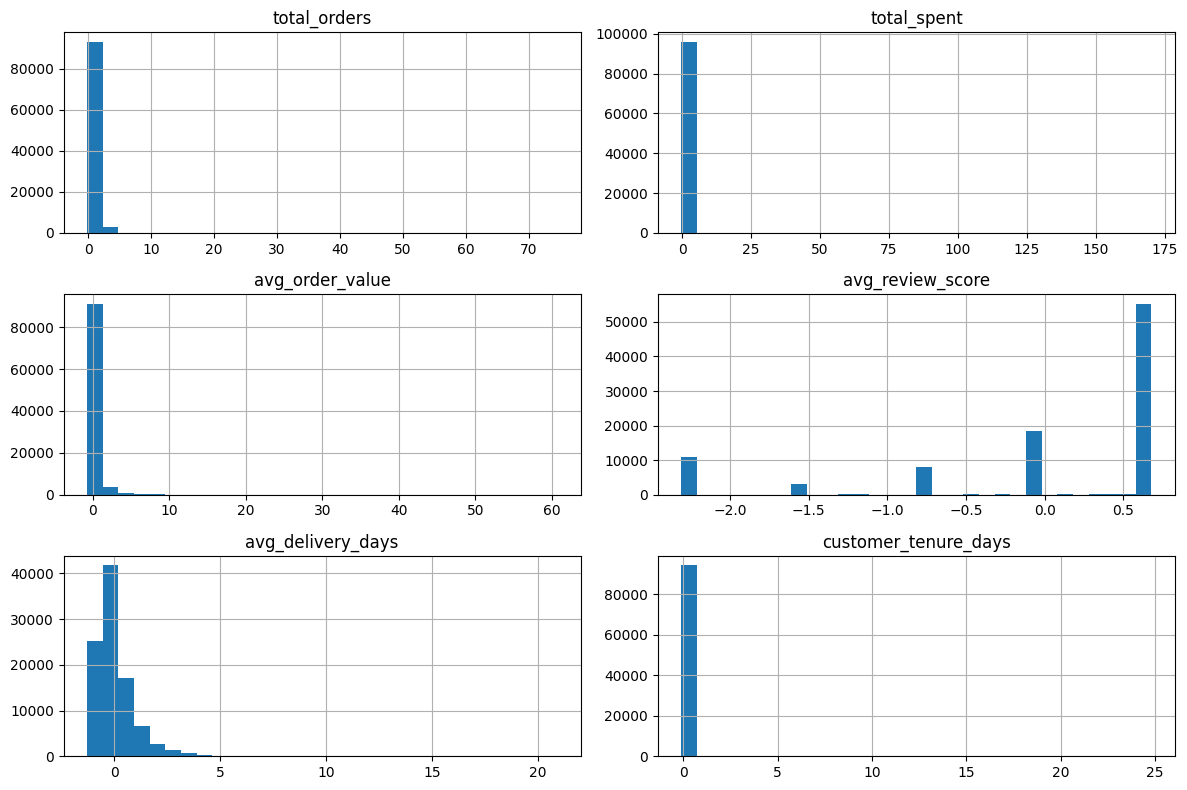

In [68]:
X_scaled.hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()

In [69]:
inertia = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/clus

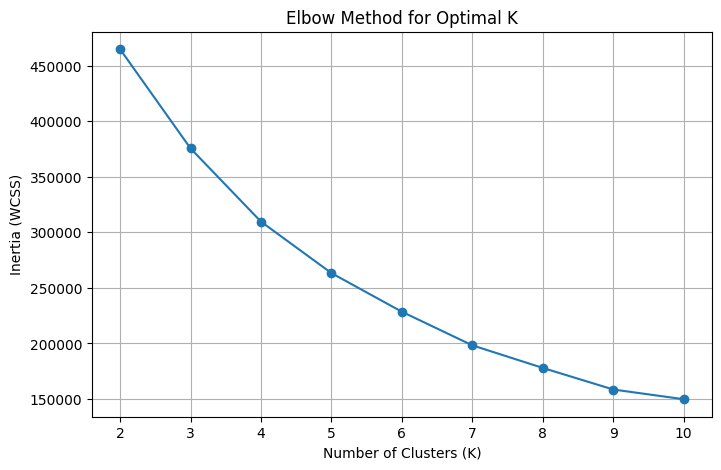

In [70]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.grid(True)

plt.show()

In [71]:
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/clus

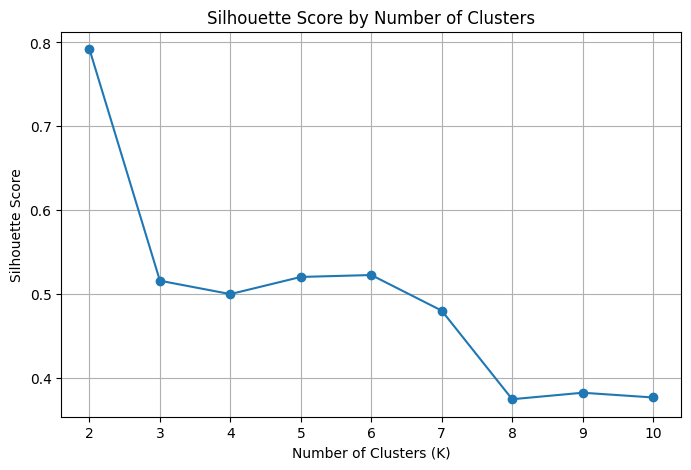

In [72]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)

plt.show()

In [73]:
evaluation = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})

evaluation

,K,Inertia,Silhouette Score
0,2,464768.342701,0.791935
1,3,375516.214177,0.515888
2,4,309590.675750,0.499922
3,5,263299.155689,0.520386
4,6,228511.698432,0.522669
5,7,198296.298872,0.480184
6,8,177969.249865,0.374573
7,9,158551.256638,0.382308
8,10,149809.781898,0.376666


In [74]:
evaluation.sort_values(
    by="Silhouette Score",
    ascending=False
)

,K,Inertia,Silhouette Score
0,2,464768.342701,0.791935
4,6,228511.698432,0.522669
3,5,263299.155689,0.520386
1,3,375516.214177,0.515888
2,4,309590.675750,0.499922
5,7,198296.298872,0.480184
7,9,158551.256638,0.382308
8,10,149809.781898,0.376666
6,8,177969.249865,0.374573


In [75]:
optimal_k = 4

In [76]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

customer_features["cluster"] = kmeans.fit_predict(X_scaled)

/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/clus

In [77]:
customer_features.head()

,customer_unique_id,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,first_purchase,last_purchase,customer_tenure_days,cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.0,6.0,2018-05-10 10:56:27,2018-05-10 10:56:27,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0,3.0,2018-05-07 11:11:27,2018-05-07 11:11:27,0,0
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0,25.0,2017-03-10 21:05:03,2017-03-10 21:05:03,0,2
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,20.0,2017-10-12 20:29:41,2017-10-12 20:29:41,0,0
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0,13.0,2017-11-14 19:45:42,2017-11-14 19:45:42,0,0


In [78]:
customer_features["cluster"].value_counts().sort_index()

cluster
0    75055
1     1293
2    17699
3     2049
Name: count, dtype: int64

In [79]:
cluster_summary = (
    customer_features["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .reset_index()
)

cluster_summary.columns = ["Cluster", "Percentage"]

cluster_summary

,Cluster,Percentage
0,0,78.10
1,1,1.35
2,2,18.42
3,3,2.13


In [80]:
customer_features.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

print("Customer segmentation dataset saved successfully!")

Customer segmentation dataset saved successfully!


In [81]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X_scaled.columns
)

centers

,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,customer_tenure_days
0,-0.082075,-0.088595,-0.125649,0.422309,-0.200586,-0.098516
1,5.746792,0.350192,-0.074442,0.116371,-0.066468,7.200347
2,-0.067754,-0.009074,-0.026832,-1.782279,0.838126,-0.097961
3,-0.034759,3.105742,4.886150,-0.148107,0.150135,-0.088870


In [82]:
cluster_profile = (
    customer_features
    .groupby("cluster")[
        [
            "total_orders",
            "total_spent",
            "avg_order_value",
            "avg_review_score",
            "avg_delivery_days",
            "customer_tenure_days"
        ]
    ]
    .mean()
    .round(2)
)

cluster_profile

,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,customer_tenure_days
cluster,,,,,,
0,1.02,156.23,133.57,4.66,10.15,0.21
1,2.27,437.47,144.98,4.25,11.42,185.55
2,1.02,207.21,155.57,1.70,19.94,0.22
3,1.03,2202.16,1248.07,3.89,13.45,0.45


In [83]:
cluster_profile = (
    customer_features
    .groupby("cluster")[
        [
            "total_orders",
            "total_spent",
            "avg_order_value",
            "avg_review_score",
            "avg_delivery_days",
            "customer_tenure_days"
        ]
    ]
    .mean()
    .round(2)
)

cluster_profile

,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,customer_tenure_days
cluster,,,,,,
0,1.02,156.23,133.57,4.66,10.15,0.21
1,2.27,437.47,144.98,4.25,11.42,185.55
2,1.02,207.21,155.57,1.70,19.94,0.22
3,1.03,2202.16,1248.07,3.89,13.45,0.45


In [84]:
cluster_size = (
    customer_features
    .groupby("cluster")
    .size()
    .rename("customer_count")
)

cluster_profile = cluster_profile.join(cluster_size)

cluster_profile

,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,customer_tenure_days,customer_count
cluster,,,,,,,
0,1.02,156.23,133.57,4.66,10.15,0.21,75055
1,2.27,437.47,144.98,4.25,11.42,185.55,1293
2,1.02,207.21,155.57,1.70,19.94,0.22,17699
3,1.03,2202.16,1248.07,3.89,13.45,0.45,2049


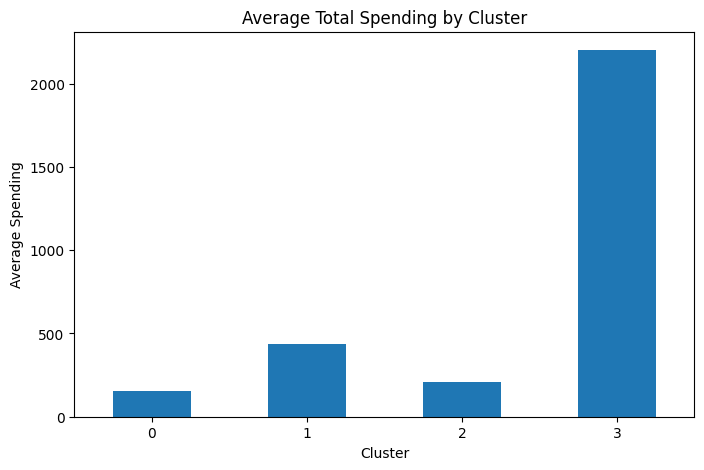

In [85]:
import matplotlib.pyplot as plt

cluster_profile["total_spent"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Total Spending by Cluster")
plt.ylabel("Average Spending")
plt.xlabel("Cluster")
plt.xticks(rotation=0)

plt.show()

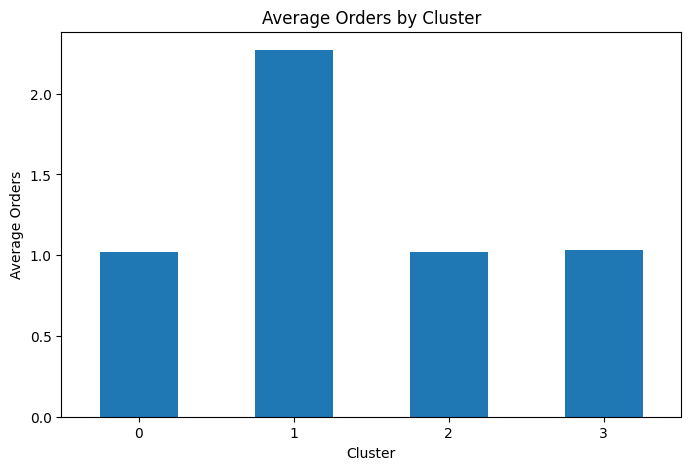

In [86]:
cluster_profile["total_orders"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Orders by Cluster")
plt.ylabel("Average Orders")
plt.xlabel("Cluster")
plt.xticks(rotation=0)

plt.show()

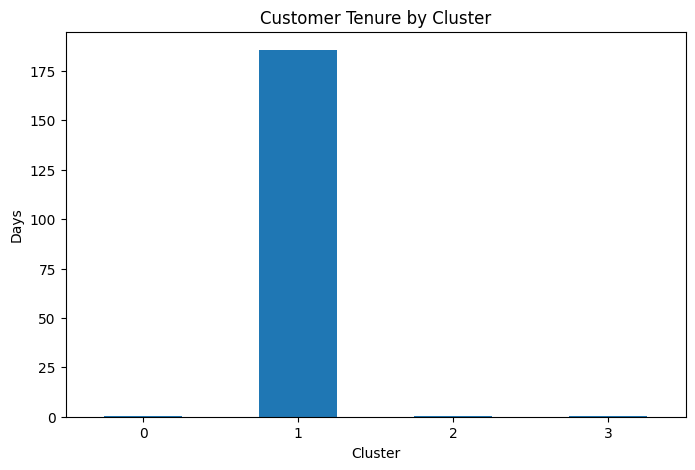

In [87]:
cluster_profile["customer_tenure_days"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Tenure by Cluster")
plt.ylabel("Days")
plt.xlabel("Cluster")
plt.xticks(rotation=0)

plt.show()

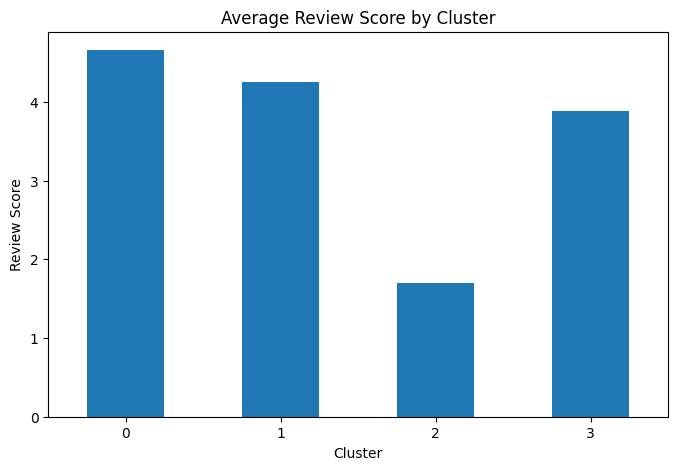

In [88]:
cluster_profile["avg_review_score"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Review Score by Cluster")
plt.ylabel("Review Score")
plt.xlabel("Cluster")
plt.xticks(rotation=0)

plt.show()

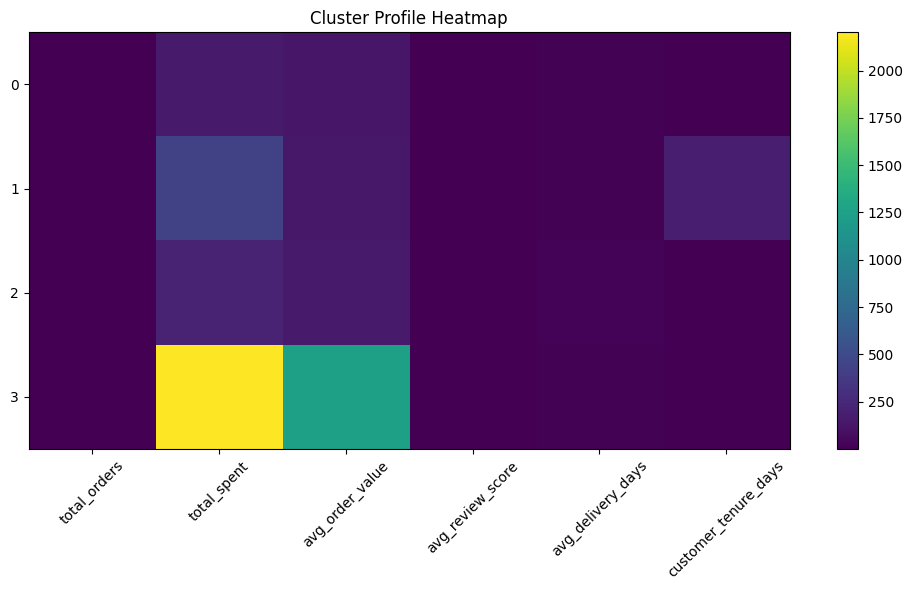

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.imshow(cluster_profile.iloc[:, :-1], aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(cluster_profile.columns[:-1])),
    cluster_profile.columns[:-1],
    rotation=45
)

plt.yticks(
    range(len(cluster_profile.index)),
    cluster_profile.index
)

plt.title("Cluster Profile Heatmap")

plt.tight_layout()

plt.show()

In [90]:
cluster_profile.to_csv(
    "../data/processed/cluster_profile.csv"
)

print("Cluster profile saved successfully!")

Cluster profile saved successfully!


In [91]:
print(df.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'purchase_year', 'purchase_month', 'purchase_day', 'purchase_weekday', 'delivery_days', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_value', 'payment_installments', 'payment_type', 'payment_count', 'review_score', 'review_count', 'review_comment_title', 'review_comment_message']


In [92]:
cluster_profile

,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,customer_tenure_days,customer_count
cluster,,,,,,,
0,1.02,156.23,133.57,4.66,10.15,0.21,75055
1,2.27,437.47,144.98,4.25,11.42,185.55,1293
2,1.02,207.21,155.57,1.70,19.94,0.22,17699
3,1.03,2202.16,1248.07,3.89,13.45,0.45,2049


In [93]:
cluster_names = {
    0: "Regular Satisfied Customers",
    1: "Loyal Repeat Customers",
    2: "At-Risk Customers",
    3: "High-Value Customers"
}

customer_features["customer_segment"] = (
    customer_features["cluster"]
    .map(cluster_names)
)

In [94]:
customer_features[
    ["customer_unique_id", "cluster", "customer_segment"]
].head()

,customer_unique_id,cluster,customer_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,0,Regular Satisfied Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0,Regular Satisfied Customers
2,0000f46a3911fa3c0805444483337064,2,At-Risk Customers
3,0000f6ccb0745a6a4b88665a16c9f078,0,Regular Satisfied Customers
4,0004aac84e0df4da2b147fca70cf8255,0,Regular Satisfied Customers


In [95]:
customer_features.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

In [96]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


In [97]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = customer_features["customer_segment"]

In [98]:
import plotly.express as px

fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="Cluster",
    title="Customer Segments (PCA Projection)",
    opacity=0.7
)

fig.update_layout(
    template="plotly_white",
    width=900,
    height=600
)

fig.show()

In [99]:
customer_features["total_orders"].describe()
customer_features["total_orders"].value_counts().head(10)

total_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64